# 03 — VAE Advanced Topics

## 📚 Learning Objectives

By completing this notebook, you will:
- Build and train a **Conditional VAE (CVAE)** and generate digits *by class*
- Implement `interpolate_latent()` and use it to morph between digits **across classes**
- Run a **β-VAE experiment**: train β = 1 vs β = 4 and measure the reconstruction ↔ regularization trade-off

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 3, lessons 01-02 (the plain VAE) and Unit 1, lesson 06, whose conditional GAN uses the same label-concatenation trick.

**Used later in:** Course 10 — Unit 3, lesson 04, where a different way of controlling generation — diffusion — takes over.

---

## Real-World Context

Controllable generation is what industry needs: a design tool must produce "a shirt in style X", not "some shirt". Conditioning and disentangled latents (β-VAE) are the two standard levers for that control.

---

## 🌍 Why this lesson exists — 12,000 models, and a negative result about β

β-VAE (Higgins et al., 2017) is famous for one claim: turn β up and the latent dimensions become *disentangled* — one axis for rotation, one for thickness, one for style. The follow-up is the part that rarely gets taught. Locatello et al. (ICML 2019 best paper, arXiv 1811.12359) trained **more than 12,000 models** across seven datasets and showed theoretically that "unsupervised learning of disentangled representations is fundamentally impossible without inductive biases on both the models and the data" — and empirically that random seeds mattered more than the choice of method, and that better disentanglement did not reduce downstream sample complexity.

So the knob you are about to turn is real and its effect is measurable — you will measure it below. The property it is famous for buying is the one that did not replicate.

**What goes wrong without this:** without a conditioning input, a generator is a slot machine: "some digit", not "a 7". And without a measured trade-off, β gets chosen by whatever number the last paper used.


## Part 1 — Conditional VAE

Same trick as the conditional GAN (unit 1, example 06): concatenate a one-hot class label to the **encoder input** and to the **decoder input**. The decoder then learns p(x | z, label) — so at generation time we choose the class and the latent handles the style.


Epoch 5/25 — loss/image: 135.3


Epoch 10/25 — loss/image: 126.9


Epoch 15/25 — loss/image: 123.6


Epoch 20/25 — loss/image: 121.4


Epoch 25/25 — loss/image: 120.1


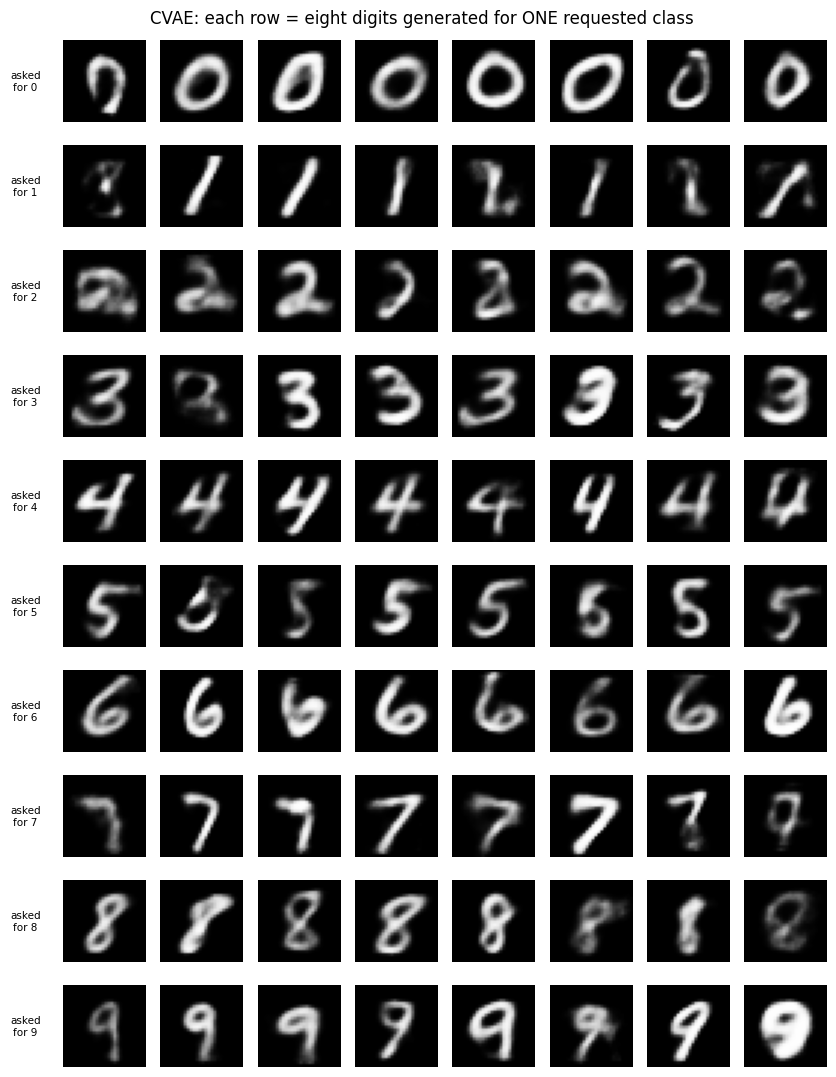

The latent z carries style (slant, thickness); the label carries WHICH digit.



Class-control check: 479/500 generated digits (96%) are
classified as the class we requested — the label input is in charge.


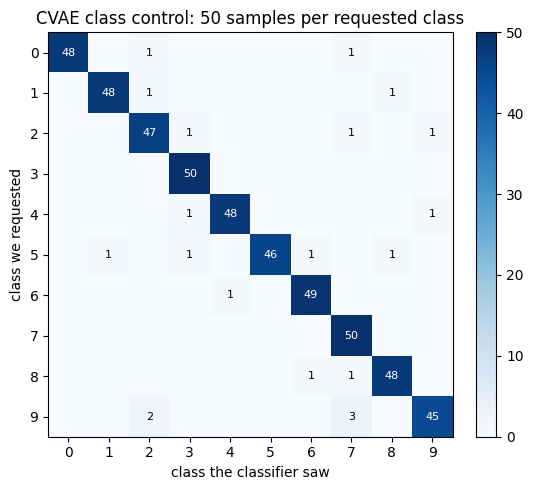

perfect rows (50/50): [3, 7]
weakest requested class: 9 — 45/50 landed on target (90% for that class, not the 96% average)
  where its misses went: 3 read as 7, 2 read as 2


In [1]:
# WHAT/WHY: build a working Conditional VAE — label goes into both encoder
# and decoder — then generate a grid where each ROW is a requested digit
# class, demonstrating label-controlled generation.
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT = 8; N_CLASSES = 10; BATCH = 128   # small z: forces class info into the label

dataset = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=T.ToTensor())
subset  = torch.utils.data.Subset(dataset, range(25_600))
loader  = torch.utils.data.DataLoader(subset, batch_size=BATCH, shuffle=True)

class ConditionalVAE(nn.Module):
    def __init__(self, z=LATENT, n_classes=N_CLASSES):
        super().__init__()
        # Encoder sees image AND label: input 784 + 10
        self.enc    = nn.Sequential(nn.Linear(784 + n_classes, 256), nn.ReLU())
        self.mu     = nn.Linear(256, z)
        self.logvar = nn.Linear(256, z)
        # Decoder sees latent AND label: input z + 10
        self.dec    = nn.Sequential(nn.Linear(z + n_classes, 256), nn.ReLU(),
                                    nn.Linear(256, 784), nn.Sigmoid())
    def encode(self, x, y_onehot):
        h = self.enc(torch.cat([x.flatten(1), y_onehot], dim=1))
        return self.mu(h), self.logvar(h)
    def decode(self, z, y_onehot):
        return self.dec(torch.cat([z, y_onehot], dim=1)).view(-1, 1, 28, 28)
    def forward(self, x, y_onehot):
        mu, lv = self.encode(x, y_onehot)
        z = mu + (0.5 * lv).exp() * torch.randn_like(mu)   # reparameterize
        return self.decode(z, y_onehot), mu, lv

cvae = ConditionalVAE()
opt  = optim.Adam(cvae.parameters(), lr=1e-3)

# ── Train: ELBO with the label fed to both halves. KL is weighted ×2 so z
# ── stays close to N(0,I) and cannot smuggle class information — the label
# ── must carry it (Part 3 examines this beta knob systematically).
EPOCHS = 25; KL_WEIGHT = 2.0
for epoch in range(EPOCHS):
    total = 0.0
    for x, y in loader:
        y1h = F.one_hot(y, N_CLASSES).float()
        recon, mu, lv = cvae(x, y1h)
        loss = (F.binary_cross_entropy(recon, x, reduction='sum')
                - KL_WEIGHT * 0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp())) / x.size(0)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — loss/image: {total/len(loader):.1f}")
cvae.eval()

# ── Class-controlled generation: each row = one requested class ───────────
fig, axes = plt.subplots(N_CLASSES, 8, figsize=(8.4, 11))
with torch.no_grad():
    for cls in range(N_CLASSES):
        z   = torch.randn(8, LATENT)
        y1h = F.one_hot(torch.full((8,), cls), N_CLASSES).float()
        imgs = cvae.decode(z, y1h)
        for j in range(8):
            axes[cls, j].imshow(imgs[j].squeeze(), cmap='gray', vmin=0, vmax=1)
            axes[cls, j].axis('off')
plt.suptitle("CVAE: each row = eight digits generated for ONE requested class")
plt.tight_layout(rect=[0.055, 0, 1, 1])
# label every row with the class we ASKED for, so the grid reads without counting.
# Positions are read AFTER tight_layout, or the labels would sit at stale y values.
for cls in range(N_CLASSES):
    pos = axes[cls, 0].get_position()
    fig.text(0.028, (pos.y0 + pos.y1) / 2, f"asked\nfor {cls}", fontsize=7.5,
             ha='center', va='center')
plt.show()
print("The latent z carries style (slant, thickness); the label carries WHICH digit.")

# ── VERIFY class control with a classifier, not just by eye ───────────────
# Train a quick digit classifier, then check how often the CVAE's output is
# classified as the class we requested.
torch.manual_seed(0)
clf = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
copt = optim.Adam(clf.parameters(), lr=1e-3); ce = nn.CrossEntropyLoss()
for epoch in range(2):
    for x, y in loader:
        l = ce(clf(x), y); copt.zero_grad(); l.backward(); copt.step()
clf.eval()
# The same 500 samples also fill a 10x10 table: what we ASKED for (rows)
# against what the classifier SAW (columns). "96% correct" hides where the
# other 4% went; the table and the heatmap below do not.
conf = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
with torch.no_grad():
    match = 0
    for cls in range(N_CLASSES):
        z   = torch.randn(50, LATENT)
        y1h = F.one_hot(torch.full((50,), cls), N_CLASSES).float()
        pred = clf(cvae.decode(z, y1h)).argmax(1)
        match += (pred == cls).sum().item()
        for p in pred.tolist():
            conf[cls, p] += 1
print(f"\nClass-control check: {match}/500 generated digits ({match/500:.0%}) are")
print("classified as the class we requested — the label input is in charge.")

# ── where do the misses go? ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.6, 5.0))
im = ax.imshow(conf, cmap='Blues')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if conf[i, j]:
            ax.text(j, i, conf[i, j], ha='center', va='center', fontsize=8,
                    color='white' if conf[i, j] > 25 else 'black')
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xlabel("class the classifier saw"); ax.set_ylabel("class we requested")
ax.set_title("CVAE class control: 50 samples per requested class")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

perfect = [c for c in range(N_CLASSES) if conf[c, c] == 50]
worst   = int(np.argmin(np.diag(conf)))
misses  = [(int(j), int(conf[worst, j])) for j in range(N_CLASSES)
           if j != worst and conf[worst, j]]
print(f"perfect rows (50/50): {perfect if perfect else 'none'}")
print(f"weakest requested class: {worst} — {conf[worst, worst]}/50 landed on target "
      f"({conf[worst, worst] / 50:.0%} for that class, not the 96% average)")
print("  where its misses went: " +
      ", ".join(f"{n} read as {j}" for j, n in sorted(misses, key=lambda t: -t[1])))


### 👁️ Read the figure

The diagonal is what we asked for; everything off it is a miss. Read the **rows**, not the
total. Classes 3 and 7 are perfect at 50/50. Class 9 is the weakest at 45/50 — and its misses
are not scattered: three were read as **7** and two as **2**. The model does not fail
uniformly; it fails on the class pairs that look alike, which is where a human would fail too.

This is the concrete answer to Discuss question 2. "96% class control" is one number averaged
over ten quite different per-class rates, produced by a two-epoch classifier that is itself
imperfect. If the client's use case is 9s, the number you owe them is 90%, not 96% — and the
matrix, not the average, is what you show them.

## Part 2 — Latent Interpolation, Including Across Classes

`interpolate_latent()` below is the general utility: interpolate two latent vectors linearly. With a CVAE we can interpolate the **label vector too** — morphing a 3 into an 8 by sliding both the style code and the (soft) class label.


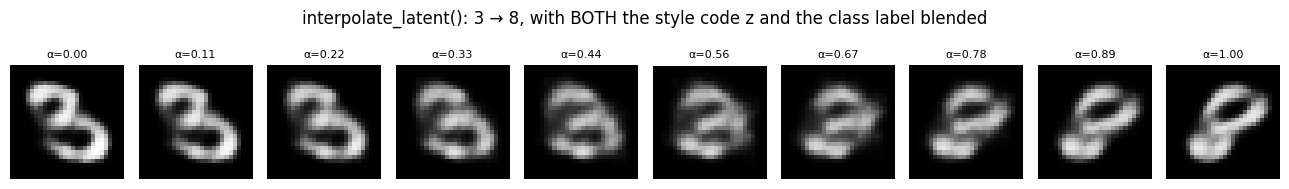

α is the blend weight: at α=0 the label is a pure one-hot 3, at α=1 a pure one-hot 8;
in between the decoder is given a label vector that is not any real class.


In [2]:
# WHAT/WHY: implement interpolate_latent() and USE it — encode a real 3 and
# a real 8, then decode the interpolation path with a blended soft label,
# producing a class-crossing morph.
def interpolate_latent(z1, z2, n_steps=10):
    """Return n_steps latent vectors linearly interpolated from z1 to z2."""
    alphas = torch.linspace(0, 1, n_steps).view(-1, 1)
    return (1 - alphas) * z1 + alphas * z2      # broadcast over latent dims

test_ds = torchvision.datasets.MNIST('/tmp/mnist', train=False, transform=T.ToTensor())
img_a = next(test_ds[i][0] for i in range(1000) if test_ds[i][1] == 3)
img_b = next(test_ds[i][0] for i in range(1000) if test_ds[i][1] == 8)
y_a = F.one_hot(torch.tensor([3]), N_CLASSES).float()
y_b = F.one_hot(torch.tensor([8]), N_CLASSES).float()

with torch.no_grad():
    z_a, _ = cvae.encode(img_a.unsqueeze(0), y_a)
    z_b, _ = cvae.encode(img_b.unsqueeze(0), y_b)
    zs = interpolate_latent(z_a, z_b, n_steps=10)          # blend the styles
    ys = interpolate_latent(y_a, y_b, n_steps=10)          # blend the labels too
    morphs = cvae.decode(zs, ys)

alphas = torch.linspace(0, 1, 10)
fig, axes = plt.subplots(1, 10, figsize=(13, 2.0))
for i, ax in enumerate(axes):
    ax.imshow(morphs[i].squeeze(), cmap='gray', vmin=0, vmax=1); ax.axis('off')
    # alpha = how much of the 8 is in the blend (0 = pure 3, 1 = pure 8)
    ax.set_title(f"α={alphas[i]:.2f}", fontsize=8)
plt.suptitle("interpolate_latent(): 3 → 8, with BOTH the style code z and the class label blended")
plt.tight_layout(); plt.show()
print("α is the blend weight: at α=0 the label is a pure one-hot 3, at α=1 a pure one-hot 8;")
print("in between the decoder is given a label vector that is not any real class.")


## Part 3 — β-VAE: Measuring the Trade-off

**β-VAE** (Higgins et al., 2017) multiplies the KL term by β > 1:

loss = reconstruction + **β** · KL

A larger β presses the latent space harder toward N(0, I), which encourages *disentangled* latent dimensions — at the cost of reconstruction quality. That trade-off is measurable, so we measure it: train β = 1 and β = 4 with identical everything else, and print each model's final reconstruction and KL components.


final per-image components   reconstruction     KL
  beta = 1                        104.6         20.5
  beta = 4                        137.8          7.2

Read the table: beta = 4 pushed KL down (a more regular, more disentangled
latent space) and reconstruction up (blurrier outputs) — the trade-off.


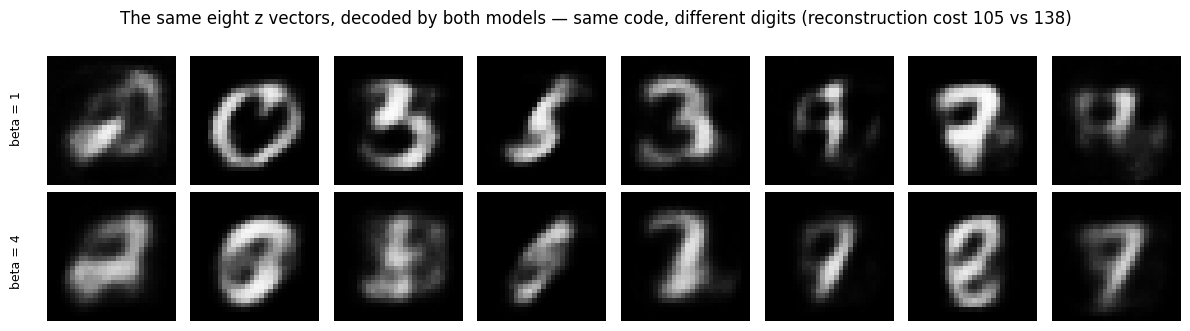

In [3]:
# WHAT/WHY: train two identical VAEs differing only in beta (1 vs 4) and
# print each one's final reconstruction-loss and KL components — making the
# beta-VAE trade-off a measured result instead of a slogan.
# ── Same VAE as before — beta is the only experimental variable ───────────
class VAE(nn.Module):
    def __init__(self, z=16):
        super().__init__()
        self.enc    = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU())
        self.mu     = nn.Linear(256, z)
        self.logvar = nn.Linear(256, z)
        self.dec    = nn.Sequential(nn.Linear(z, 256), nn.ReLU(),
                                    nn.Linear(256, 784), nn.Sigmoid())
    def forward(self, x):
        h = self.enc(x)
        mu, lv = self.mu(h), self.logvar(h)
        z = mu + (0.5 * lv).exp() * torch.randn_like(mu)
        return self.dec(z).view(-1, 1, 28, 28), mu, lv

def train_beta_vae(beta, epochs=4):
    """Train one VAE with the given beta.

    Returns the model, its final per-image (recon, kl), and the per-epoch
    history of both components so the next cell can plot the trade-off as it
    forms rather than only as a final pair of numbers.
    """
    torch.manual_seed(0)                       # identical init for a fair comparison
    model = VAE(); opt = optim.Adam(model.parameters(), lr=1e-3)
    hist = []
    for epoch in range(epochs):
        recon_sum = kl_sum = 0.0
        for x, _ in loader:
            recon, mu, lv = model(x)
            recon_loss = F.binary_cross_entropy(recon, x, reduction='sum') / x.size(0)
            kl_loss    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / x.size(0)
            loss = recon_loss + beta * kl_loss          # <-- the only difference
            opt.zero_grad(); loss.backward(); opt.step()
            recon_sum += recon_loss.item(); kl_sum += kl_loss.item()
        hist.append((recon_sum / len(loader), kl_sum / len(loader)))
    return model, recon_sum / len(loader), kl_sum / len(loader), hist

# ── Run the experiment: identical models and data, beta = 1 vs beta = 4 ───
vae_b1, recon1, kl1, hist1 = train_beta_vae(beta=1)
vae_b4, recon4, kl4, hist4 = train_beta_vae(beta=4)

print("final per-image components   reconstruction     KL")
print(f"  beta = 1                      {recon1:7.1f}       {kl1:6.1f}")
print(f"  beta = 4                      {recon4:7.1f}       {kl4:6.1f}")
print("\nRead the table: beta = 4 pushed KL down (a more regular, more disentangled")
print("latent space) and reconstruction up (blurrier outputs) — the trade-off.")

# ── Show samples from both, same latent draws ─────────────────────────────
torch.manual_seed(7)
z = torch.randn(8, 16)
with torch.no_grad():
    s1 = vae_b1.dec(z).view(-1, 28, 28)
    s4 = vae_b4.dec(z).view(-1, 28, 28)
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for j in range(8):
    axes[0, j].imshow(s1[j], cmap='gray', vmin=0, vmax=1); axes[0, j].axis('off')
    axes[1, j].imshow(s4[j], cmap='gray', vmin=0, vmax=1); axes[1, j].axis('off')
# row labels outside the image grid, so they cannot sit on top of a digit
fig.text(0.012, 0.66, "beta = 1", fontsize=9, rotation=90, va='center')
fig.text(0.012, 0.24, "beta = 4", fontsize=9, rotation=90, va='center')
plt.suptitle(f"The same eight z vectors, decoded by both models — same code, different digits "
             f"(reconstruction cost {recon1:.0f} vs {recon4:.0f})")
plt.tight_layout(rect=[0.03, 0, 1, 1]); plt.show()


### 👁️ Read the figure

Both rows decode the **same eight z vectors**, and the two rows do not match. Column 3 goes
from a clear 3 under β = 1 to a rounded 5 under β = 4; column 7 goes from a clean 7 to a
two-loop shape. Other columns survive the change — column 2 is a 0 in both rows. That is the
first thing to take from the picture: **β did not only change quality, it changed what z
means.** The two models built different latent spaces, so the same coordinate lands somewhere
else in each.

The second thing is the sharpness difference, and here you should trust the number more than
your eye: β = 4's reconstruction cost is 138 against β = 1's 105. Some individual tiles in the
β = 4 row look perfectly crisp; the penalty is an average over the whole dataset, not a promise
about any one sample. That is exactly why the next cell plots the components per epoch instead
of asking you to judge blur from eight pictures.

## The Trade-off, Epoch by Epoch

Two final numbers per model tell you *that* there is a trade-off. The figure below shows
*when* it appears and how the two runs move apart — the same histories, no retraining.

epoch |  recon b=1   KL b=1 |  recon b=4   KL b=4
    1 |      202.7     10.8 |      219.3      2.7
    2 |      133.5     16.1 |      161.2      5.0
    3 |      113.6     19.2 |      146.9      6.3
    4 |      104.6     20.5 |      137.8      7.2


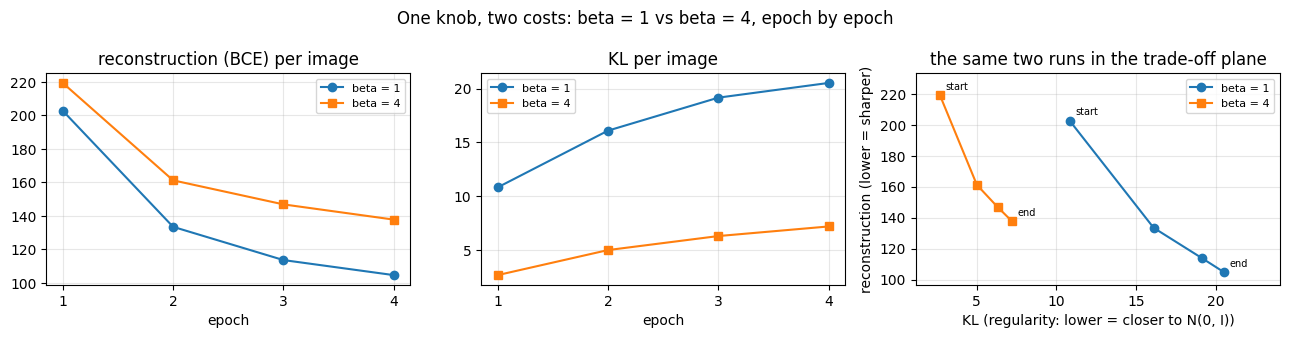

In [4]:
# WHAT/WHY: the table above is the last row of a story. Here is the whole
# story: both loss components for both betas at every epoch, and the same two
# runs drawn in the (KL, reconstruction) plane where the trade-off lives.
# Reuses the history recorded during the runs above — no extra training.
ep = range(1, len(hist1) + 1)
r1, k1 = [h[0] for h in hist1], [h[1] for h in hist1]
r4, k4 = [h[0] for h in hist4], [h[1] for h in hist4]

print(f"{'epoch':>5} | {'recon b=1':>10} {'KL b=1':>8} | {'recon b=4':>10} {'KL b=4':>8}")
for i, e in enumerate(ep):
    print(f"{e:>5} | {r1[i]:>10.1f} {k1[i]:>8.1f} | {r4[i]:>10.1f} {k4[i]:>8.1f}")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].plot(ep, r1, 'o-', label="beta = 1"); ax[0].plot(ep, r4, 's-', label="beta = 4")
ax[0].set_title("reconstruction (BCE) per image"); ax[0].set_xlabel("epoch")
ax[0].set_xticks(list(ep)); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].plot(ep, k1, 'o-', label="beta = 1"); ax[1].plot(ep, k4, 's-', label="beta = 4")
ax[1].set_title("KL per image"); ax[1].set_xlabel("epoch")
ax[1].set_xticks(list(ep)); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

ax[2].plot(k1, r1, 'o-', label="beta = 1"); ax[2].plot(k4, r4, 's-', label="beta = 4")
for kk, rr in ((k1, r1), (k4, r4)):
    ax[2].annotate("start", (kk[0], rr[0]), fontsize=7, xytext=(4, 4), textcoords='offset points')
    ax[2].annotate("end",   (kk[-1], rr[-1]), fontsize=7, xytext=(4, 4), textcoords='offset points')
# headroom so the "start"/"end" labels are not clipped by the axes edge
_r_all = r1 + r4
ax[2].set_ylim(min(_r_all) - 8, max(_r_all) + 14)
ax[2].set_xlim(min(k1 + k4) - 1.5, max(k1 + k4) + 3.5)
ax[2].set_xlabel("KL (regularity: lower = closer to N(0, I))")
ax[2].set_ylabel("reconstruction (lower = sharper)")
ax[2].set_title("the same two runs in the trade-off plane")
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)
plt.suptitle("One knob, two costs: beta = 1 vs beta = 4, epoch by epoch")
plt.tight_layout(); plt.show()


### 👁️ Read the figures

**Left and middle.** β = 4's KL sits below β = 1's from the very first epoch (2.7 against 10.8)
and never crosses it; its reconstruction sits above from the first epoch too (219.3 against
202.7) and never crosses back. The trade-off is not something that emerges after long
training — the objective sets it on the first pass through the data.

**Both runs are still improving at epoch 4.** Neither reconstruction curve has flattened, so
read 104.6 against 137.8 as "where these two runs stood at epoch 4", not as converged values.
That is the honest caveat to attach to the comparison before you quote it.

**Right — the same two runs in the trade-off plane.** Each run travels *down* (reconstruction
improving) and *to the right* (KL growing) as it trains, and the two paths stay in separate
regions the whole way. β is not a quality dial with a best setting; it chooses which of two
lanes your run travels in, and you pick the lane from what the model is for.

## 💬 Discuss

1. β = 4 cut KL from **20.5 to 7.2** and raised reconstruction from **104.6 to 137.8**. Which model would you ship for (a) an anomaly detector built on reconstruction error, and (b) a design tool with latent sliders? Justify each from those four numbers.
2. **96% (479/500)** of generated digits were classified as the class we requested. What is the other 4%, and would you report "96% class control" to a client without qualification? What qualification would you add?
3. Locatello et al. found seeds mattered more than methods for disentanglement. What would you have to run — concretely, in this notebook — before you were entitled to claim that β = 4 "disentangled" our latent space?


## ⚠️ Where this breaks

**β-VAE buys regularity, not interpretability.** A lower KL means a latent closer to N(0, I). It does not mean the axes correspond to human concepts, and Locatello et al. (2019) showed the objective alone cannot deliver that without inductive bias or supervision. Report the KL/reconstruction trade-off you measured; do not report "disentanglement" unless you measured that too.

**Class control is not a class guarantee.** 4% of our samples went to the wrong class, and the classifier that measured that is itself imperfect. In any regulated setting, that verification step is part of the *system*, not part of the evaluation — it has to run in production, on every batch.

**The class-crossing morph is extrapolation.** Interpolating the soft label feeds the decoder label vectors it never saw in training (0.5 of a "3" plus 0.5 of an "8"). The intermediate frames look convincing because the decoder always outputs something digit-shaped — that is not evidence the path is meaningful.

**Higher β costs you the reconstruction you may actually need.** At β = 4 the reconstruction loss rose by 32%. If the downstream job is anomaly detection, you have just raised the error floor that small defects have to exceed (see example 01's limits).


## 📚 References & Further Reading

**Papers:**
- Sohn et al. (2015) — [Conditional VAE](https://papers.nips.cc/paper/5775-learning-structured-output-representation-using-deep-conditional-generative-models)
- Higgins et al. (2017) — [β-VAE: Learning Basic Visual Concepts](https://openreview.net/forum?id=Sy2fchgcx)
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114)
- Vahdat & Kautz (2020) — [NVAE: A Deep Hierarchical Variational Autoencoder](https://arxiv.org/abs/2007.03898) *(the hierarchical VAE mentioned below)*
- Page et al. (2026) — [Boosting Latent Diffusion Models via Disentangled Representation Alignment](https://arxiv.org/abs/2601.05823) *(β-VAE's live descendant: disentanglement pursued not for human interpretability but to make the downstream generator train faster — the paper reports FID 1.21 on ImageNet 256×256 with classifier-free guidance)*
- Hansen-Estruch et al. (2025) — [Learnings from Scaling Visual Tokenizers for Reconstruction and Generation](https://arxiv.org/abs/2501.09755) *(the same reconstruction-versus-regularity trade-off you measure with β, studied at scale)*

**Beyond this notebook:** hierarchical VAEs (NVAE), VQ-VAE (the discrete-latent VAE inside DALL-E 1)


## 📝 Summary

In **03 — VAE Advanced Topics** you built the two standard control mechanisms and measured one trade-off:
- A **Conditional VAE** whose generation you steer by class — verified two ways: the 10-row figure, and a classifier check reporting how often samples match the requested class (printed percentage)
- **`interpolate_latent()`**, implemented and used for a class-crossing 3 → 8 morph
- A **β-VAE experiment** with printed evidence: β = 4 lowered the KL component and raised reconstruction loss relative to β = 1 — regularity bought at the price of fidelity

Next: example 04 leaves the VAE family for **diffusion models** — the architecture behind Stable Diffusion.
